# Assignment 2: Credit Card Fraud Detection Using ANN


In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Loaded file:", file_name)
print("Dataset shape:", df.shape)
df.head()

Saving creditcard.csv to creditcard.csv
Loaded file: creditcard.csv
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  

Total missing values: 0

Missing values by column:
No missing values found.

Duplicate rows: 1081

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


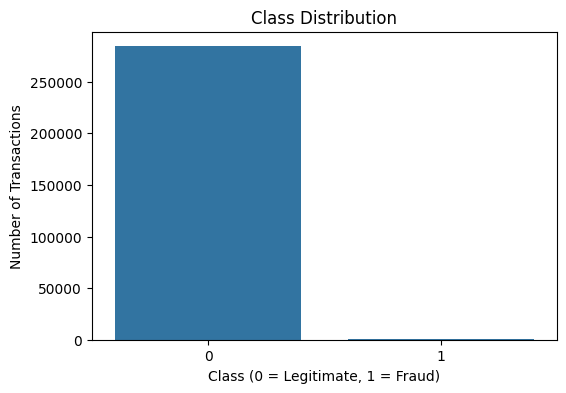

In [4]:
print("Total missing values:", int(df.isna().sum().sum()))

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values by column:")
print(missing[missing > 0] if (missing > 0).any() else "No missing values found.")

duplicate_count = int(df.duplicated().sum())
print("\nDuplicate rows:", duplicate_count)

print("\nClass distribution:")
class_counts = df["Class"].value_counts().sort_index()
print(class_counts)

class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100
print("\nClass percentages:")
print(class_percent.round(4))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

           count          mean           std         min           25%  \
Time    284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1      284807.0  1.168375e-15      1.958696  -56.407510     -0.920373   
V2      284807.0  3.416908e-16      1.651309  -72.715728     -0.598550   
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4      284807.0  2.074095e-15      1.415869   -5.683171     -0.848640   
V5      284807.0  9.604066e-16      1.380247 -113.743307     -0.691597   
V6      284807.0  1.487313e-15      1.332271  -26.160506     -0.768296   
V7      284807.0 -5.556467e-16      1.237094  -43.557242     -0.554076   
V8      284807.0  1.213481e-16      1.194353  -73.216718     -0.208630   
V9      284807.0 -2.406331e-15      1.098632  -13.434066     -0.643098   
V10     284807.0  2.239053e-15      1.088850  -24.588262     -0.535426   
V11     284807.0  1.673327e-15      1.020713   -4.797473     -0.762494   
V12     284807.0 -1.247012e-15      0.

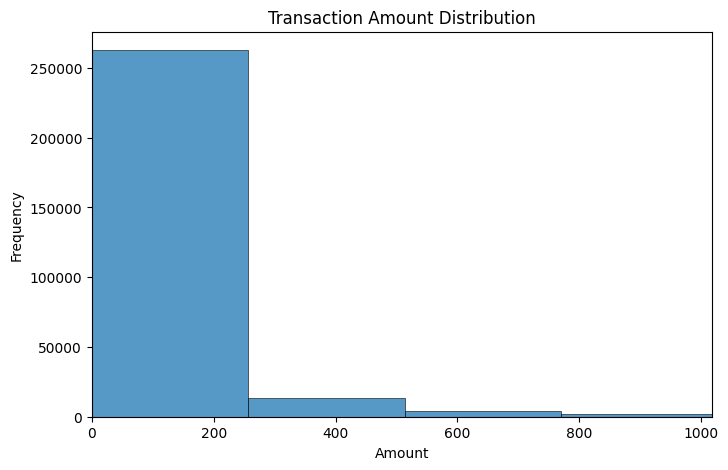


Amount statistics by class:


,count,mean,median,max
Class,,,,
0,284315,88.291022,22.00,25691.16
1,492,122.211321,9.25,2125.87


In [5]:
print(df.describe().T)

plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=100, kde=False)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.xlim(0, df["Amount"].quantile(0.99))
plt.show()

fraud_amount = df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"])
print("\nAmount statistics by class:")
display(fraud_amount)

Features ranked by absolute correlation with Class:


,Correlation
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


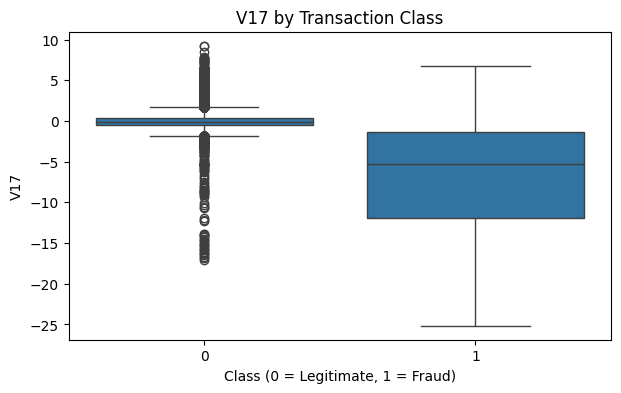

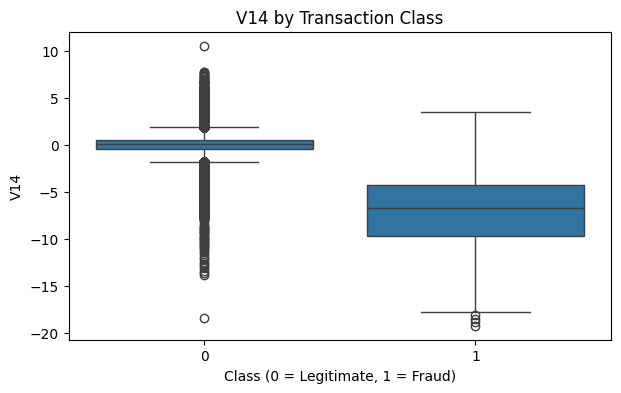

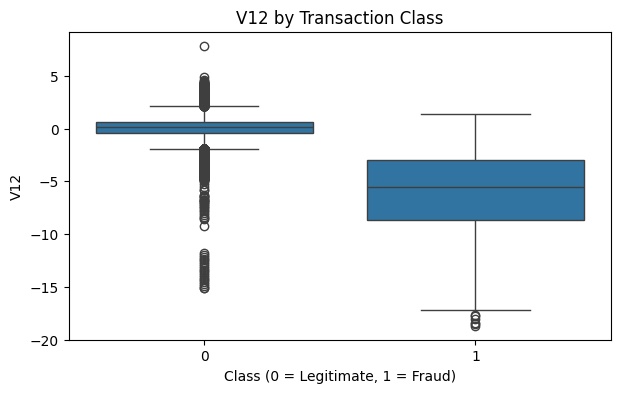

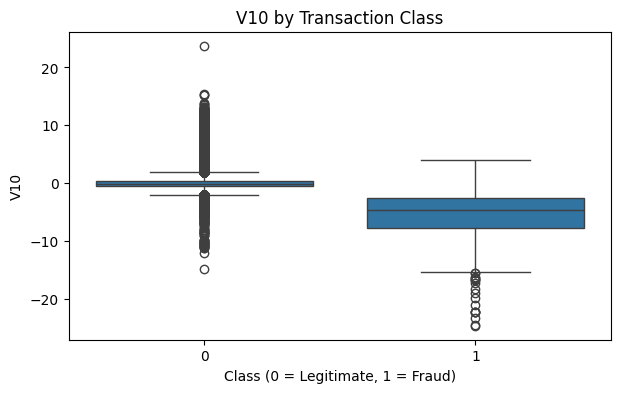

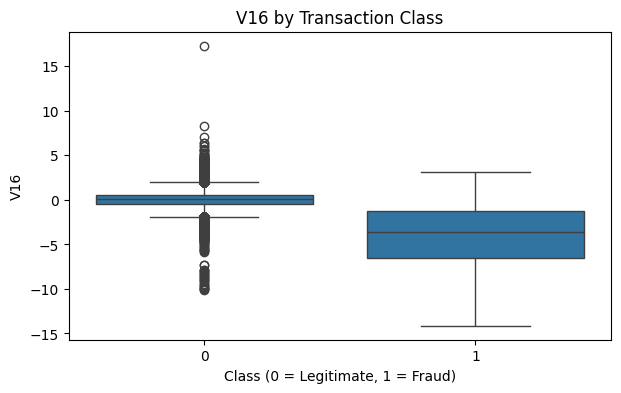

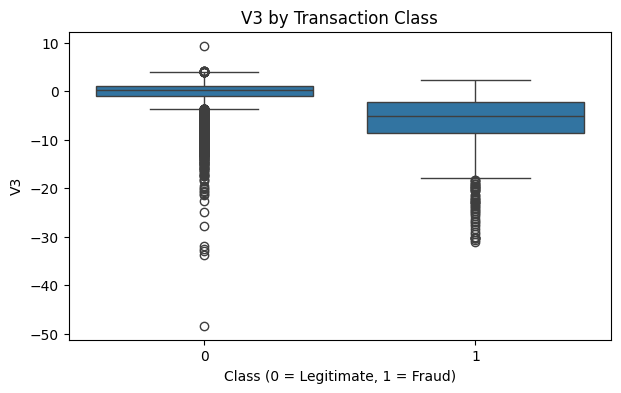

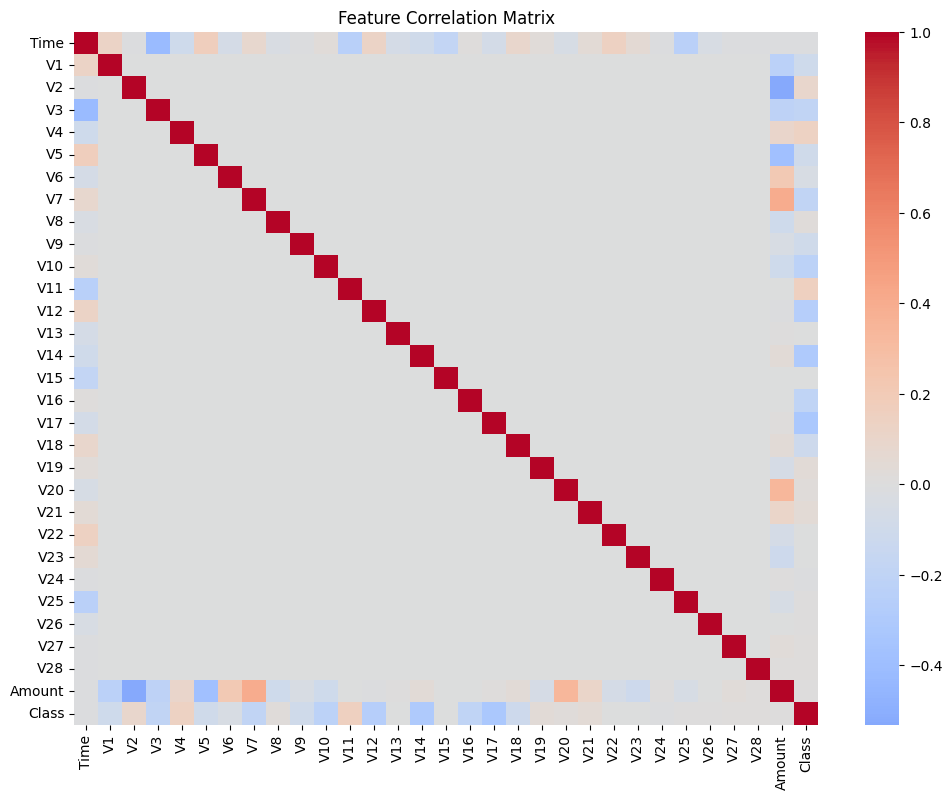

In [6]:
corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values(key=np.abs, ascending=False)

print("Features ranked by absolute correlation with Class:")
display(corr.to_frame("Correlation"))

top_features = corr.abs().head(6).index.tolist()

for feature in top_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="Class", y=feature)
    plt.title(f"{feature} by Transaction Class")
    plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
    plt.show()

plt.figure(figsize=(12,9))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [7]:
df_clean = df.drop_duplicates().reset_index(drop=True)

print("Original shape:", df.shape)
print("Shape after removing duplicates:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())

X = df_clean.drop(columns=["Class"]).copy()
y = df_clean["Class"].astype(int).copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

Original shape: (284807, 31)
Shape after removing duplicates: (283726, 31)
Duplicates remaining: 0
Feature shape: (283726, 30)
Target shape: (283726,)
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Validation:", X_val.shape, y_val.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (198608, 30) {0: 198277, 1: 331}
Validation: (42559, 30) {0: 42488, 1: 71}
Test: (42559, 30) {0: 42488, 1: 71}


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Mean of first 5 scaled features:", X_train_scaled[:, :5].mean(axis=0).round(4))
print("Std of first 5 scaled features:", X_train_scaled[:, :5].std(axis=0).round(4))

Scaled train shape: (198608, 30)
Mean of first 5 scaled features: [-0.  0.  0. -0. -0.]
Std of first 5 scaled features: [1. 1. 1. 1. 1.]


In [10]:
classes = np.unique(y_train)
total = len(y_train)

class_weight = {
    int(c): total / (len(classes) * np.sum(y_train == c))
    for c in classes
}

print("Class weights:")
print(class_weight)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).sort_index())

Class weights:
{0: np.float64(0.5008346908617742), 1: np.float64(300.012084592145)}

Training distribution:
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [11]:
def build_ann(input_dim, activation="relu", optimizer_name="adam", units=(64, 32), dropout=0.20):
    model = keras.Sequential(name=f"ANN_{activation}_{optimizer_name}")
    model.add(layers.Input(shape=(input_dim,)))

    for i, n_units in enumerate(units):
        model.add(layers.Dense(n_units, activation=activation))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1, activation="sigmoid"))

    if optimizer_name.lower() == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name.lower() == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)
    else:
        raise ValueError("Unknown optimizer")

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    return model

print("Input features:", X_train_scaled.shape[1])

Input features: 30


In [12]:
def evaluate_model(model, X_data, y_data, threshold=0.5):
    probabilities = model.predict(X_data, batch_size=2048, verbose=0).ravel()
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(y_data, predictions, zero_division=0),
        "Recall": recall_score(y_data, predictions, zero_division=0),
        "F1": f1_score(y_data, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_data, probabilities),
        "PR_AUC": average_precision_score(y_data, probabilities)
    }

def plot_confusion(model, X_data, y_data, title, threshold=0.5):
    probabilities = model.predict(X_data, batch_size=2048, verbose=0).ravel()
    predictions = (probabilities >= threshold).astype(int)
    cm = confusion_matrix(y_data, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(
        y_data, predictions,
        target_names=["Legitimate (0)", "Fraud (1)"],
        zero_division=0
    ))

In [13]:
BASE_UNITS = (64, 32)
BASE_EPOCHS = 50
BASE_BATCH = 512

activation_names = ["relu", "tanh", "sigmoid"]
optimizer_names = ["adam", "sgd", "rmsprop"]

activation_optimizer_results = []
activation_optimizer_models = {}
activation_optimizer_histories = {}

for activation in activation_names:
    for optimizer in optimizer_names:
        print(f"\nTraining: Activation={activation.upper()}, Optimizer={optimizer.upper()}")

        tf.keras.backend.clear_session()
        model = build_ann(
            X_train_scaled.shape[1],
            activation=activation,
            optimizer_name=optimizer,
            units=BASE_UNITS,
            dropout=0.20
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ]

        history = model.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=BASE_EPOCHS,
            batch_size=BASE_BATCH,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0
        )

        metrics = evaluate_model(model, X_val_scaled, y_val)

        activation_optimizer_results.append({
            "Experiment": "Activation + Optimizer",
            "Model": f"{activation.upper()} + {optimizer.upper()}",
            "Activation": activation.upper(),
            "Optimizer": optimizer.upper(),
            "Architecture": str(BASE_UNITS),
            "Epochs": len(history.history["loss"]),
            "Batch Size": BASE_BATCH,
            **metrics
        })

        activation_optimizer_models[f"{activation}_{optimizer}"] = model
        activation_optimizer_histories[f"{activation}_{optimizer}"] = history

activation_optimizer_df = pd.DataFrame(activation_optimizer_results).sort_values(
    ["F1", "Recall", "Precision"], ascending=False
).reset_index(drop=True)

display(activation_optimizer_df)


Training: Activation=RELU, Optimizer=ADAM

Training: Activation=RELU, Optimizer=SGD

Training: Activation=RELU, Optimizer=RMSPROP

Training: Activation=TANH, Optimizer=ADAM

Training: Activation=TANH, Optimizer=SGD

Training: Activation=TANH, Optimizer=RMSPROP

Training: Activation=SIGMOID, Optimizer=ADAM

Training: Activation=SIGMOID, Optimizer=SGD

Training: Activation=SIGMOID, Optimizer=RMSPROP


,Experiment,Model,Activation,Optimizer,Architecture,Epochs,Batch Size,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Activation + Optimizer,RELU + RMSPROP,RELU,RMSPROP,"(64, 32)",11,512,0.996100,0.281106,0.859155,0.423611,0.966371,0.712107
1,Activation + Optimizer,TANH + RMSPROP,TANH,RMSPROP,"(64, 32)",14,512,0.992246,0.161880,0.873239,0.273128,0.978879,0.773609
2,Activation + Optimizer,SIGMOID + RMSPROP,SIGMOID,RMSPROP,"(64, 32)",12,512,0.991001,0.142202,0.873239,0.244576,0.978196,0.675735
3,Activation + Optimizer,RELU + ADAM,RELU,ADAM,"(64, 32)",25,512,0.987782,0.109565,0.887324,0.195046,0.971625,0.720931
4,Activation + Optimizer,TANH + ADAM,TANH,ADAM,"(64, 32)",24,512,0.984140,0.085165,0.873239,0.155194,0.978646,0.724339
5,Activation + Optimizer,TANH + SGD,TANH,SGD,"(64, 32)",18,512,0.981626,0.076281,0.901408,0.140659,0.972168,0.725033
6,Activation + Optimizer,RELU + SGD,RELU,SGD,"(64, 32)",10,512,0.973190,0.053422,0.901408,0.100867,0.982981,0.725499
7,Activation + Optimizer,SIGMOID + ADAM,SIGMOID,ADAM,"(64, 32)",11,512,0.969102,0.045985,0.887324,0.087439,0.978901,0.694685
8,Activation + Optimizer,SIGMOID + SGD,SIGMOID,SGD,"(64, 32)",11,512,0.962523,0.038741,0.901408,0.074289,0.977357,0.708142


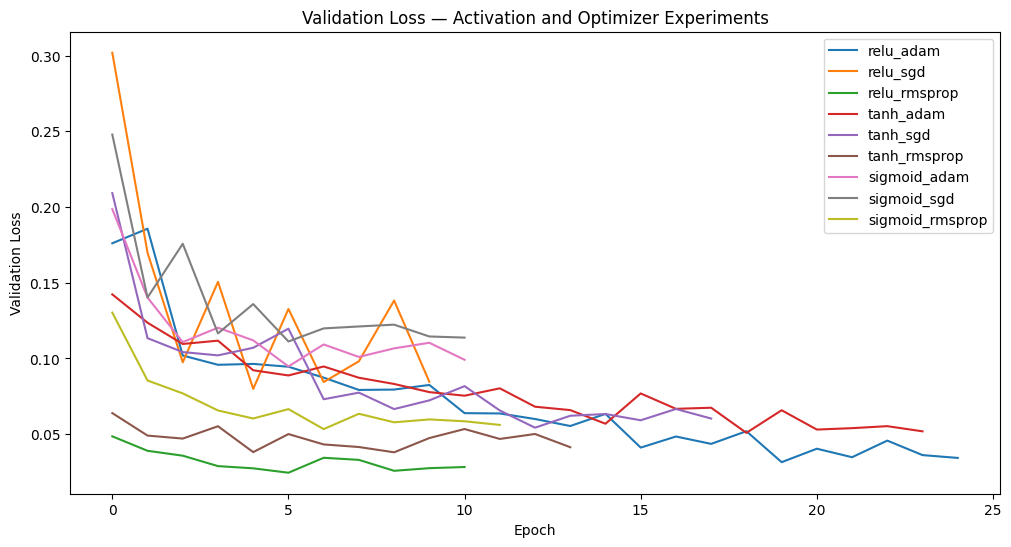

In [14]:
plt.figure(figsize=(12,6))

for key, history in activation_optimizer_histories.items():
    plt.plot(history.history["val_loss"], label=key)

plt.title("Validation Loss — Activation and Optimizer Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [15]:
best_ao_row = activation_optimizer_df.iloc[0]

best_activation = best_ao_row["Activation"].lower()
best_optimizer = best_ao_row["Optimizer"].lower()

best_ao_key = f"{best_activation}_{best_optimizer}"
best_ao_model = activation_optimizer_models[best_ao_key]

print("Best activation:", best_activation.upper())
print("Best optimizer:", best_optimizer.upper())
print("Validation metrics:")
display(best_ao_row.to_frame("Value"))

Best activation: RELU
Best optimizer: RMSPROP
Validation metrics:


,Value
Experiment,Activation + Optimizer
Model,RELU + RMSPROP
Activation,RELU
Optimizer,RMSPROP
Architecture,"(64, 32)"
Epochs,11
Batch Size,512
Accuracy,0.9961
Precision,0.281106
Recall,0.859155


In [16]:
architectures = {
    "Small": (32, 16),
    "Medium": (64, 32),
    "Deep": (128, 64, 32)
}

architecture_results = []
architecture_models = {}
architecture_histories = {}

for arch_name, units in architectures.items():
    print(f"\nTraining architecture: {arch_name} {units}")

    tf.keras.backend.clear_session()
    model = build_ann(
        X_train_scaled.shape[1],
        activation=best_activation,
        optimizer_name=best_optimizer,
        units=units,
        dropout=0.20
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=BASE_BATCH,
        class_weight=class_weight,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    architecture_results.append({
        "Experiment": "Architecture",
        "Model": arch_name,
        "Activation": best_activation.upper(),
        "Optimizer": best_optimizer.upper(),
        "Architecture": str(units),
        "Epochs": len(history.history["loss"]),
        "Batch Size": BASE_BATCH,
        **metrics
    })

    architecture_models[arch_name] = model
    architecture_histories[arch_name] = history

architecture_df = pd.DataFrame(architecture_results).sort_values(
    ["F1", "Recall", "Precision"], ascending=False
).reset_index(drop=True)

display(architecture_df)


Training architecture: Small (32, 16)

Training architecture: Medium (64, 32)

Training architecture: Deep (128, 64, 32)


,Experiment,Model,Activation,Optimizer,Architecture,Epochs,Batch Size,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Architecture,Small,RELU,RMSPROP,"(32, 16)",15,512,0.994784,0.225455,0.873239,0.358382,0.962251,0.695744
1,Architecture,Medium,RELU,RMSPROP,"(64, 32)",19,512,0.994243,0.208054,0.873239,0.336043,0.961243,0.718807
2,Architecture,Deep,RELU,RMSPROP,"(128, 64, 32)",12,512,0.991259,0.145882,0.873239,0.250000,0.966289,0.718629


In [17]:
epoch_settings = [20, 50, 100]
epoch_results = []
epoch_models = {}
epoch_histories = {}

best_arch_name = architecture_df.iloc[0]["Model"]
best_units = architectures[best_arch_name]

for epochs in epoch_settings:
    print(f"\nTraining for {epochs} epochs")

    tf.keras.backend.clear_session()
    model = build_ann(
        X_train_scaled.shape[1],
        activation=best_activation,
        optimizer_name=best_optimizer,
        units=best_units,
        dropout=0.20
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epochs,
        batch_size=BASE_BATCH,
        class_weight=class_weight,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    epoch_results.append({
        "Experiment": "Epochs",
        "Model": f"{epochs} Epochs",
        "Activation": best_activation.upper(),
        "Optimizer": best_optimizer.upper(),
        "Architecture": str(best_units),
        "Epochs": len(history.history["loss"]),
        "Requested Epochs": epochs,
        "Batch Size": BASE_BATCH,
        **metrics
    })

    epoch_models[epochs] = model
    epoch_histories[epochs] = history

epoch_df = pd.DataFrame(epoch_results).sort_values(
    ["F1", "Recall", "Precision"], ascending=False
).reset_index(drop=True)

display(epoch_df)


Training for 20 epochs

Training for 50 epochs

Training for 100 epochs


,Experiment,Model,Activation,Optimizer,Architecture,Epochs,Requested Epochs,Batch Size,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Epochs,20 Epochs,RELU,RMSPROP,"(32, 16)",20,20,512,0.996804,0.324324,0.845070,0.468750,0.967696,0.698581
1,Epochs,100 Epochs,RELU,RMSPROP,"(32, 16)",10,100,512,0.996194,0.288372,0.873239,0.433566,0.957783,0.710747
2,Epochs,50 Epochs,RELU,RMSPROP,"(32, 16)",13,50,512,0.996053,0.276498,0.845070,0.416667,0.961989,0.702100


In [18]:
batch_settings = [256, 512, 1024]
batch_results = []
batch_models = {}
batch_histories = {}

for batch_size in batch_settings:
    print(f"\nTraining with batch size {batch_size}")

    tf.keras.backend.clear_session()
    model = build_ann(
        X_train_scaled.shape[1],
        activation=best_activation,
        optimizer_name=best_optimizer,
        units=best_units,
        dropout=0.20
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    batch_results.append({
        "Experiment": "Batch Size",
        "Model": f"Batch {batch_size}",
        "Activation": best_activation.upper(),
        "Optimizer": best_optimizer.upper(),
        "Architecture": str(best_units),
        "Epochs": len(history.history["loss"]),
        "Requested Epochs": 50,
        "Batch Size": batch_size,
        **metrics
    })

    batch_models[batch_size] = model
    batch_histories[batch_size] = history

batch_df = pd.DataFrame(batch_results).sort_values(
    ["F1", "Recall", "Precision"], ascending=False
).reset_index(drop=True)

display(batch_df)


Training with batch size 256

Training with batch size 512

Training with batch size 1024


,Experiment,Model,Activation,Optimizer,Architecture,Epochs,Requested Epochs,Batch Size,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Batch Size,Batch 256,RELU,RMSPROP,"(32, 16)",11,50,256,0.998943,0.641304,0.830986,0.723926,0.945862,0.704644
1,Batch Size,Batch 512,RELU,RMSPROP,"(32, 16)",13,50,512,0.996264,0.292453,0.873239,0.438163,0.967645,0.714950
2,Batch Size,Batch 1024,RELU,RMSPROP,"(32, 16)",18,50,1024,0.993820,0.196203,0.873239,0.320413,0.970176,0.718653


In [19]:
all_experiments_df = pd.concat([
    activation_optimizer_df,
    architecture_df,
    epoch_df.drop(columns=["Requested Epochs"], errors="ignore"),
    batch_df.drop(columns=["Requested Epochs"], errors="ignore")
], ignore_index=True)

comparison_columns = [
    "Experiment", "Model", "Activation", "Optimizer", "Architecture",
    "Epochs", "Batch Size", "Accuracy", "Precision", "Recall", "F1",
    "ROC_AUC", "PR_AUC"
]

all_experiments_df = all_experiments_df[comparison_columns].copy()
all_experiments_df = all_experiments_df.sort_values(
    ["F1", "Recall", "Precision"], ascending=False
).reset_index(drop=True)

display(all_experiments_df.round(4))

,Experiment,Model,Activation,Optimizer,Architecture,Epochs,Batch Size,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Batch Size,Batch 256,RELU,RMSPROP,"(32, 16)",11,256,0.9989,0.6413,0.8310,0.7239,0.9459,0.7046
1,Epochs,20 Epochs,RELU,RMSPROP,"(32, 16)",20,512,0.9968,0.3243,0.8451,0.4688,0.9677,0.6986
2,Batch Size,Batch 512,RELU,RMSPROP,"(32, 16)",13,512,0.9963,0.2925,0.8732,0.4382,0.9676,0.7150
3,Epochs,100 Epochs,RELU,RMSPROP,"(32, 16)",10,512,0.9962,0.2884,0.8732,0.4336,0.9578,0.7107
4,Activation + Optimizer,RELU + RMSPROP,RELU,RMSPROP,"(64, 32)",11,512,0.9961,0.2811,0.8592,0.4236,0.9664,0.7121
5,Epochs,50 Epochs,RELU,RMSPROP,"(32, 16)",13,512,0.9961,0.2765,0.8451,0.4167,0.9620,0.7021
6,Architecture,Small,RELU,RMSPROP,"(32, 16)",15,512,0.9948,0.2255,0.8732,0.3584,0.9623,0.6957
7,Architecture,Medium,RELU,RMSPROP,"(64, 32)",19,512,0.9942,0.2081,0.8732,0.3360,0.9612,0.7188
8,Batch Size,Batch 1024,RELU,RMSPROP,"(32, 16)",18,1024,0.9938,0.1962,0.8732,0.3204,0.9702,0.7187
9,Activation + Optimizer,TANH + RMSPROP,TANH,RMSPROP,"(64, 32)",14,512,0.9922,0.1619,0.8732,0.2731,0.9789,0.7736


In [20]:
best_row = all_experiments_df.iloc[0]

best_activation_final = best_row["Activation"].lower()
best_optimizer_final = best_row["Optimizer"].lower()
best_units_final = tuple(int(x.strip()) for x in best_row["Architecture"].strip("()").split(",") if x.strip())
best_batch_final = int(best_row["Batch Size"])

# If architecture string has a trailing comma for a one-layer tuple, filter handles it.
if len(best_units_final) == 0:
    best_units_final = best_units

print("Best validation experiment:")
display(best_row.to_frame("Value"))

print("\nSelection rule:")
print("1. Highest validation F1-score")
print("2. If needed, higher fraud Recall")
print("3. If still needed, higher Precision")
print("\nThis is more appropriate for fraud detection than selecting the model only by Accuracy.")

Best validation experiment:


,Value
Experiment,Batch Size
Model,Batch 256
Activation,RELU
Optimizer,RMSPROP
Architecture,"(32, 16)"
Epochs,11
Batch Size,256
Accuracy,0.998943
Precision,0.641304
Recall,0.830986



Selection rule:
1. Highest validation F1-score
2. If needed, higher fraud Recall
3. If still needed, higher Precision

This is more appropriate for fraud detection than selecting the model only by Accuracy.


In [21]:
tf.keras.backend.clear_session()

final_model = build_ann(
    X_train_scaled.shape[1],
    activation=best_activation_final,
    optimizer_name=best_optimizer_final,
    units=best_units_final,
    dropout=0.20
)

final_epochs = int(best_row["Epochs"])
if final_epochs < 1:
    final_epochs = 50

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=final_epochs,
    batch_size=best_batch_final,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

print("Final model architecture:")
final_model.summary()

Epoch 1/11
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9768 - loss: 0.3864 - precision: 0.0540 - recall: 0.7825 - val_accuracy: 0.9973 - val_loss: 0.0229 - val_precision: 0.3602 - val_recall: 0.8169
Epoch 2/11
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9972 - loss: 0.3437 - precision: 0.3538 - recall: 0.8338 - val_accuracy: 0.9982 - val_loss: 0.0152 - val_precision: 0.4833 - val_recall: 0.8169
Epoch 3/11
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9970 - loss: 0.3581 - precision: 0.3412 - recall: 0.8338 - val_accuracy: 0.9976 - val_loss: 0.0149 - val_precision: 0.3960 - val_recall: 0.8310
Epoch 4/11
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9967 - loss: 0.3475 - precision: 0.3143 - recall: 0.8459 - val_accuracy: 0.9971 - val_loss: 0.0150 - val_precision: 0.3430 - val_recall: 0.8310
Epoch 5/11
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9965 - loss: 0.3192 - precision: 0.3013 - recall: 0.8429 - val_accuracy: 0.9979 - val_loss: 0.

Model: "ANN_relu_rmsprop"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,076 (12.02 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,539 (6.02 KB)

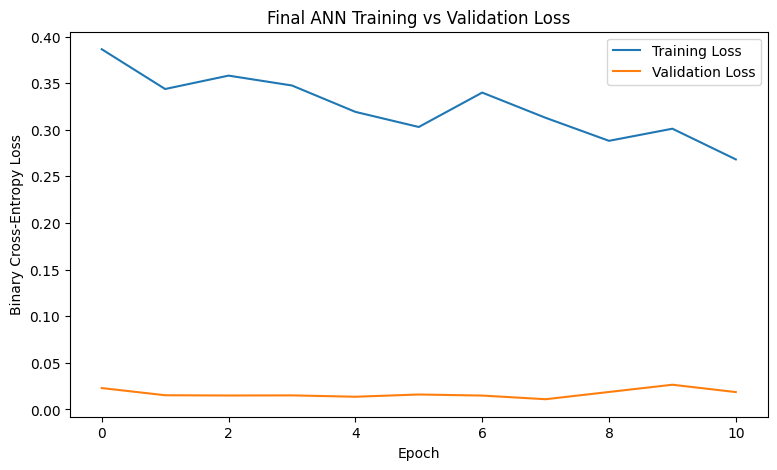

Best validation-loss epoch: 8
Minimum validation loss: 0.010919271036982536


In [22]:
plt.figure(figsize=(9,5))
plt.plot(final_history.history["loss"], label="Training Loss")
plt.plot(final_history.history["val_loss"], label="Validation Loss")
plt.title("Final ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

best_epoch_idx = int(np.argmin(final_history.history["val_loss"]))
print("Best validation-loss epoch:", best_epoch_idx + 1)
print("Minimum validation loss:", float(np.min(final_history.history["val_loss"])))

Final Test Metrics
Accuracy  : 0.9988
Precision : 0.6042
Recall    : 0.8169
F1        : 0.6946
ROC_AUC   : 0.9490
PR_AUC    : 0.6947


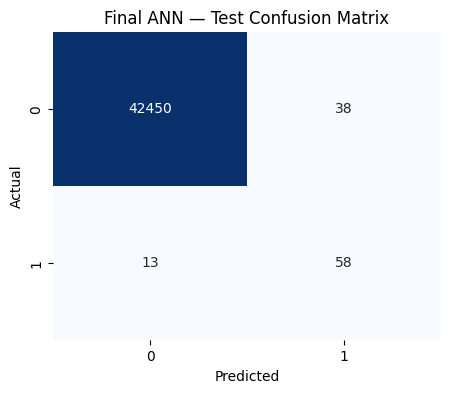

                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     42488
     Fraud (1)       0.60      0.82      0.69        71

      accuracy                           1.00     42559
     macro avg       0.80      0.91      0.85     42559
  weighted avg       1.00      1.00      1.00     42559



In [23]:
test_metrics = evaluate_model(final_model, X_test_scaled, y_test)

print("Final Test Metrics")
for metric, value in test_metrics.items():
    print(f"{metric:10s}: {value:.4f}")

plot_confusion(
    final_model,
    X_test_scaled,
    y_test,
    "Final ANN — Test Confusion Matrix"
)

In [24]:
test_probabilities = final_model.predict(
    X_test_scaled, batch_size=2048, verbose=0
).ravel()

test_predictions = (test_probabilities >= 0.5).astype(int)

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Legitimate (0)", "Fraud (1)"],
    digits=4,
    zero_division=0
))

tn, fp, fn, tp = confusion_matrix(y_test, test_predictions).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)
print("\nFraud Recall interpretation:")
print(f"The model detected {tp} of the {tp + fn} actual fraud transactions in the test set.")

                precision    recall  f1-score   support

Legitimate (0)     0.9997    0.9991    0.9994     42488
     Fraud (1)     0.6042    0.8169    0.6946        71

      accuracy                         0.9988     42559
     macro avg     0.8019    0.9080    0.8470     42559
  weighted avg     0.9990    0.9988    0.9989     42559

True Negatives : 42450
False Positives: 38
False Negatives: 13
True Positives  : 58

Fraud Recall interpretation:
The model detected 58 of the 71 actual fraud transactions in the test set.


In [25]:
sample_n = 20
sample_indices = np.random.RandomState(SEED).choice(
    len(X_test), size=min(sample_n, len(X_test)), replace=False
)

sample_predictions_df = pd.DataFrame({
    "Actual Class": y_test.iloc[sample_indices].values,
    "Predicted Probability of Fraud": test_probabilities[sample_indices],
    "Predicted Class": test_predictions[sample_indices]
})

sample_predictions_df["Actual Meaning"] = sample_predictions_df["Actual Class"].map({
    0: "Legitimate",
    1: "Fraudulent"
})
sample_predictions_df["Predicted Meaning"] = sample_predictions_df["Predicted Class"].map({
    0: "Legitimate",
    1: "Fraudulent"
})

display(sample_predictions_df)

,Actual Class,Predicted Probability of Fraud,Predicted Class,Actual Meaning,Predicted Meaning
0,0,0.000578,0,Legitimate,Legitimate
1,0,0.002294,0,Legitimate,Legitimate
2,0,0.000736,0,Legitimate,Legitimate
3,0,0.007249,0,Legitimate,Legitimate
4,0,0.000191,0,Legitimate,Legitimate
5,0,0.000148,0,Legitimate,Legitimate
6,0,0.001904,0,Legitimate,Legitimate
7,0,0.000003,0,Legitimate,Legitimate
8,0,0.000618,0,Legitimate,Legitimate
9,0,0.000347,0,Legitimate,Legitimate


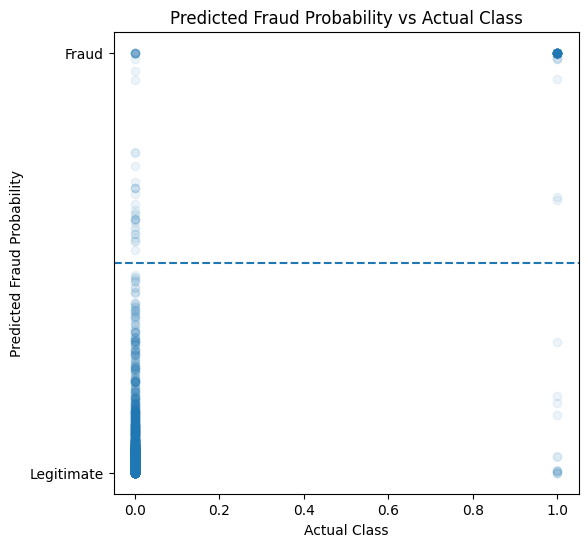

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, test_probabilities, alpha=0.08)
plt.axhline(0.5, linestyle="--")
plt.yticks([0, 1], ["Legitimate", "Fraud"])
plt.xlabel("Actual Class")
plt.ylabel("Predicted Fraud Probability")
plt.title("Predicted Fraud Probability vs Actual Class")
plt.show()

In [27]:
train_loss = np.array(final_history.history["loss"])
val_loss = np.array(final_history.history["val_loss"])

best_val_loss = float(val_loss.min())
best_val_epoch = int(val_loss.argmin()) + 1
train_at_best = float(train_loss[best_val_epoch - 1])
final_train_loss = float(train_loss[-1])
final_val_loss = float(val_loss[-1])

gap = final_val_loss - final_train_loss
relative_gap = gap / max(abs(final_train_loss), 1e-8)

print(f"Best validation loss: {best_val_loss:.5f} at epoch {best_val_epoch}")
print(f"Training loss at that epoch: {train_at_best:.5f}")
print(f"Final training loss: {final_train_loss:.5f}")
print(f"Final validation loss: {final_val_loss:.5f}")
print(f"Final validation-training loss gap: {gap:.5f}")

if val_loss[-1] > best_val_loss * 1.05:
    print("\nInterpretation: validation loss increased noticeably after its minimum, suggesting some overfitting.")
else:
    print("\nInterpretation: validation loss stayed relatively close to its minimum; strong overfitting is not evident.")

print("\nOverfitting controls used:")
print("- Dropout in hidden layers")
print("- Validation monitoring")
print("- EarlyStopping with restore_best_weights=True")

Best validation loss: 0.01092 at epoch 8
Training loss at that epoch: 0.31282
Final training loss: 0.26819
Final validation loss: 0.01858
Final validation-training loss gap: -0.24961

Interpretation: validation loss increased noticeably after its minimum, suggesting some overfitting.

Overfitting controls used:
- Dropout in hidden layers
- Validation monitoring
- EarlyStopping with restore_best_weights=True


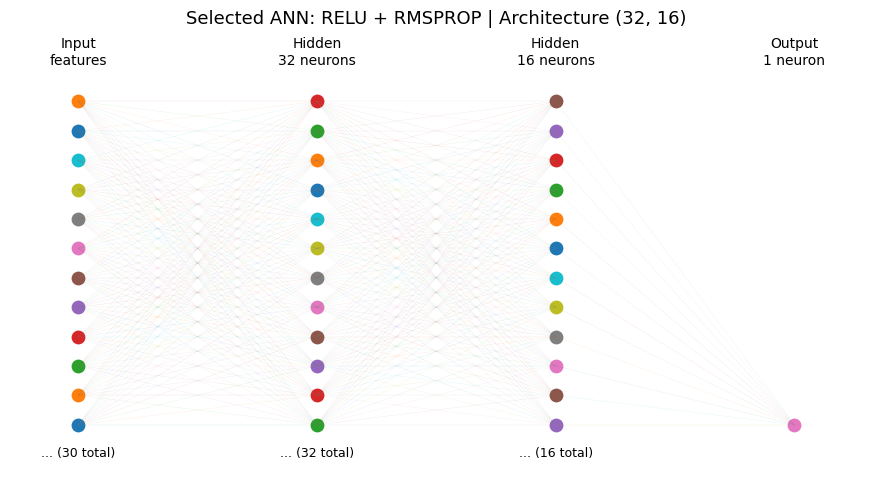

In [28]:
input_dim = X_train_scaled.shape[1]
layer_sizes = [input_dim] + list(best_units_final) + [1]
layer_labels = ["Input\nfeatures"] + [f"Hidden\n{n} neurons" for n in best_units_final] + ["Output\n1 neuron"]

fig, ax = plt.subplots(figsize=(11,6))
x_positions = np.linspace(0.08, 0.92, len(layer_sizes))

for i, (x, size, label) in enumerate(zip(x_positions, layer_sizes, layer_labels)):
    display_nodes = min(size, 12)
    ys = np.linspace(0.15, 0.85, display_nodes)

    for y_node in ys:
        ax.scatter(x, y_node, s=80)

    if size > display_nodes:
        ax.text(x, 0.08, f"... ({size} total)", ha="center", fontsize=9)
    ax.text(x, 0.93, label, ha="center", fontsize=10)

    if i < len(layer_sizes) - 1:
        next_x = x_positions[i+1]
        next_size = layer_sizes[i+1]
        next_display = min(next_size, 12)
        next_ys = np.linspace(0.15, 0.85, next_display)

        for y1 in ys:
            for y2 in next_ys:
                ax.plot([x, next_x], [y1, y2], linewidth=0.25, alpha=0.15)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis("off")
ax.set_title(
    f"Selected ANN: {best_activation_final.upper()} + {best_optimizer_final.upper()} | "
    f"Architecture {best_units_final}",
    fontsize=13
)
plt.show()

In [29]:
test_cm = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = test_cm.ravel()




### Conclusion

A feed-forward Artificial Neural Network (ANN) was developed to classify credit-card transactions as legitimate (Class 0) or fraudulent (Class 1). The dataset was inspected through exploratory data analysis, missing values were checked, and exact duplicate rows were removed before the data was divided into training, validation, and test sets. The target column `Class` was excluded from the input features.

Because the dataset is highly imbalanced, class weights were applied during training. This approach increases the learning importance of fraud transactions while keeping the validation and test sets at their realistic class distribution. Numerical features were standardized using `StandardScaler`, fitted only on the training data.

Multiple ANN experiments were performed using ReLU, Tanh and Sigmoid hidden-layer activations, together with Adam, SGD and RMSprop optimizers. Different hidden-layer architectures, epoch settings (20, 50 and 100) and batch sizes were also 

In [30]:
final_test_row = pd.DataFrame([{
    "Model": "Final Selected ANN",
    "Activation": best_activation_final.upper(),
    "Optimizer": best_optimizer_final.upper(),
    "Architecture": str(best_units_final),
    "Epochs": len(final_history.history["loss"]),
    "Batch Size": best_batch_final,
    **test_metrics
}])

all_experiments_df.to_csv("ANN_FRAUD_ALL_EXPERIMENTS.csv", index=False)
sample_predictions_df.to_csv("ANN_FRAUD_SAMPLE_PREDICTIONS.csv", index=False)
final_test_row.to_csv("ANN_FRAUD_FINAL_TEST_RESULTS.csv", index=False)

final_model.save("BEST_CREDIT_CARD_FRAUD_ANN.keras")

print("Saved files:")
print("- ANN_FRAUD_ALL_EXPERIMENTS.csv")
print("- ANN_FRAUD_SAMPLE_PREDICTIONS.csv")
print("- ANN_FRAUD_FINAL_TEST_RESULTS.csv")
print("- BEST_CREDIT_CARD_FRAUD_ANN.keras")

Saved files:
- ANN_FRAUD_ALL_EXPERIMENTS.csv
- ANN_FRAUD_SAMPLE_PREDICTIONS.csv
- ANN_FRAUD_FINAL_TEST_RESULTS.csv
- BEST_CREDIT_CARD_FRAUD_ANN.keras
